In [1]:
using CMPSExcitations

In [23]:
function projection_matrix(D, R)
    dim_in = D^2 + D      # input: E (DxD) + F (D)
    dim_out = 2 * D^2     # output: W1, W2 (both DxD)
    P = zeros(ComplexF64, dim_out, dim_in)

    Dr, M = eigen(R)

    for j in 1:dim_in
        e = zeros(Float64, dim_in)
        e[j] = 1.0

        E = reshape(view(e, 1:D^2), D, D)
        F = view(e, D^2+1:dim_in)

        W1 = E - M * Diagonal(F) / M
        W2 = E + M * Diagonal(F) / M

        P[:, j] = vcat(vec(W1), vec(W2))
    end

    return Matrix(qr(P).Q) # moves to an orthogonal projection
end

function excitation_matrix(Heff, D)
    dim = 2 * D^2
    M = zeros(ComplexF64, dim, dim)

    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        W1 = reshape(view(e, 1:D^2), D, D)
        W2 = reshape(view(e, D^2+1:dim), D, D)
        W1p, W2p = Heff((Constant(W1), Constant(W2)))
        M[:, j] = vcat(vec(W1p[]), vec(W2p[]))
    end

    return M
end

function excitation_matrix_left(Heff, D, ρR)
    dim = 2 * D^2
    M = zeros(ComplexF64, dim, dim)
    factor = sqrt(ρR)
    
    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        W1 = reshape(view(e, 1:D^2), D, D)
        W2 = reshape(view(e, D^2+1:dim), D, D)
        W1 = W1 * factor
        W2 = W2 * factor
        W1p, W2p = Heff((Constant(W1), Constant(W2)))
        W1p = W1p / factor 
        W2p = W2p / factor
        M[:, j] = vcat(vec(W1p[]), vec(W2p[]))
    end

    return M
end

function leftcanonical(state, cmps=false)
    leftgauge!(state)
    r = rightenv(state)[1][]
    D, U = eigen(r)
    Q = U \ state.Q[] * U
    R = U \ state.Rs[1][] * U
    return (cmps) ? InfiniteCMPS(Constant(Q), (Constant(R), Constant(R))) : (Q, R)
end

function left2centre_matrix(ρR)
    D = size(ρR, 1)
    dim = 2 * D^2
    M = zeros(ComplexF64, dim, dim)
    factor = sqrt(ρR) # generally can be any C such that CC' = r

    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        W1 = reshape(view(e, 1:D^2), D, D)
        W2 = reshape(view(e, D^2+1:dim), D, D)
        X1, X2 = W1 * factor, W2 * factor
        M[:, j] = vcat(vec(X1), vec(X2))
    end

    return M
end

function leftgaugetv(Q, R, V, W1, W2, p)
    # assuming Q, R are in cMPS left gauge
    X, _ = linsolve(-R' * (W1 + W2) - V) do X
        (Q * X - X * Q) + 1im * p * X + 2 * R' * (R * X - X * R)
    end

    return V + (Q * X - X * Q) + 1im * p * X, W1 + (R * X - X * R), W2 + (R * X - X * R)
end

leftgaugetv (generic function with 1 method)

In [30]:
Hsingle_cll(c, μ) = ∫(2 * ∂ψ̂' * ∂ψ̂ - 2 * μ * ψ̂' * ψ̂ + 4 * c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));
Hcoupled(c, μ) = ∫(
    (∂ψ̂₁' * ∂ψ̂₁ - μ * ψ̂₁' * ψ̂₁ + c * (ψ̂₁')^2 * ψ̂₁^2 +
     ∂ψ̂₂' * ∂ψ̂₂ - μ * ψ̂₂' * ψ̂₂ + c * (ψ̂₂')^2 * ψ̂₂^2 +
     c * (ψ̂₁') * (ψ̂₂') * ψ̂₂ * ψ̂₁ + c * (ψ̂₂') * (ψ̂₁') * ψ̂₁ * ψ̂₂), (-Inf, +Inf));

Hsingle_ll(c, μ) = ∫(∂ψ̂' * ∂ψ̂ - μ * ψ̂' * ψ̂ + c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));

In [21]:
c, μ = 10., 5.
tol = 1e-10
Ds = [10]
D = maximum(Ds)

HLL = Hsingle_cll(c, μ)
stateLL = find_groundstate(Ds, HLL, YangGaudinCMPS, optalg=LBFGS(80; verbosity=1, maxiter=7000, gradtol=tol), gradtol=tol)
println("Energy density: ", expval(HLL.h, stateLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateLL)[], "\n Order parameter: ", expval(ψ̂, stateLL)[])
println("------------")
HCLL = Hcoupled(c, μ)
stateCLL = InfiniteCMPS(stateLL.Q, (stateLL.Rs[1], stateLL.Rs[1]));
leftgauge!(stateCLL)
println("Energy density: ", expval(HCLL.h, stateCLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateCLL)[], "\n Order parameter: ", expval(ψ̂, stateCLL)[])

Optimizing D=10


┌ Info: YangGaudinCMPS ground state: initialization with e = 11991.468057850445
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:106
┌ Info: LBFGS: converged after 1250 iterations: f = -2.763283122856, ‖∇f‖ = 8.7267e-11
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138


D = 10 | YangGaudinCMPS{Constant{Matrix{Float64}}, 1}
 28.045590 seconds (19.36 M allocations: 2.358 GiB, 0.53% gc time)
---------------
Energy density: -2.763283122856281
 Particle density: 0.4367562721871287
 Order parameter: 0.3438074627530441
------------
Energy density: -2.7632831228563934

┌ Info: YangGaudinCMPS ground state: converged after 1251 iterations: e = -2.763283122856, ‖∇e‖ = 8.7267e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:118



 Particle density: 0.4367562721871224
 Order parameter: 0.34380746275304325


In [32]:
Hl = excitation_matrix_left(excitation_operator(HCLL, space), D, ρR);

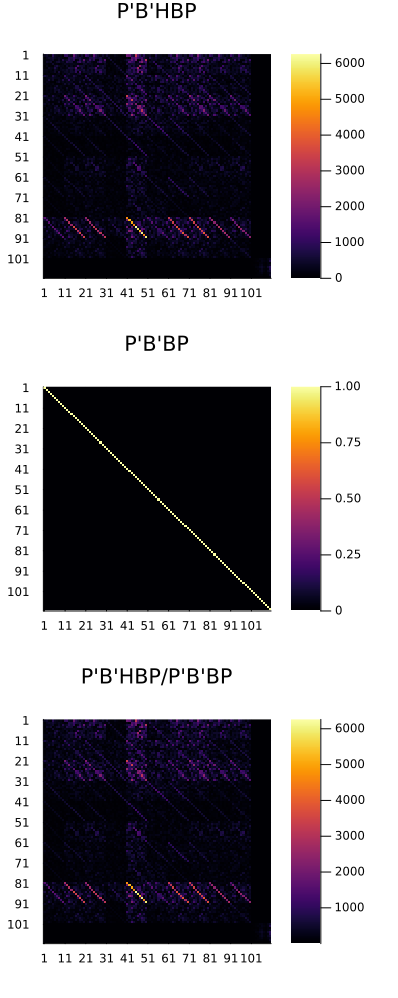

In [38]:
# stateCLL = leftcanonical(stateCLL, true)
P = projection_matrix(D, stateLL.Rs[1][])

ρR = rightenv(stateCLL)[1][]
ρR ./= tr(ρR)
B = left2centre_matrix(ρR)

space = InfiniteCMPSExcitationSpace(0, stateCLL, stateCLL)
Heff = excitation_matrix_left(excitation_operator(HCLL, space), D, ρR);

Hf = P' * Heff * P
Nf = P' * P

p1 = heatmap(abs.(Hf), yflip=true, size=(400, 400), xticks=1:D:D^2+D, yticks=1:D:D^2+D, title="P'B'HBP")
p2 = heatmap(abs.(Nf), yflip=true, size=(400, 400), xticks=1:D:D^2+D, yticks=1:D:D^2+D, title="P'B'BP")
p3 = heatmap(abs.(Hf / Nf), yflip=true, size=(400, 400), xticks=1:D:D^2+D, yticks=1:D:D^2+D, title="P'B'HBP/P'B'BP")

plot(p1, p2, p3, layout=(3, 1), size=(400, 1000), margins=5Plots.mm)

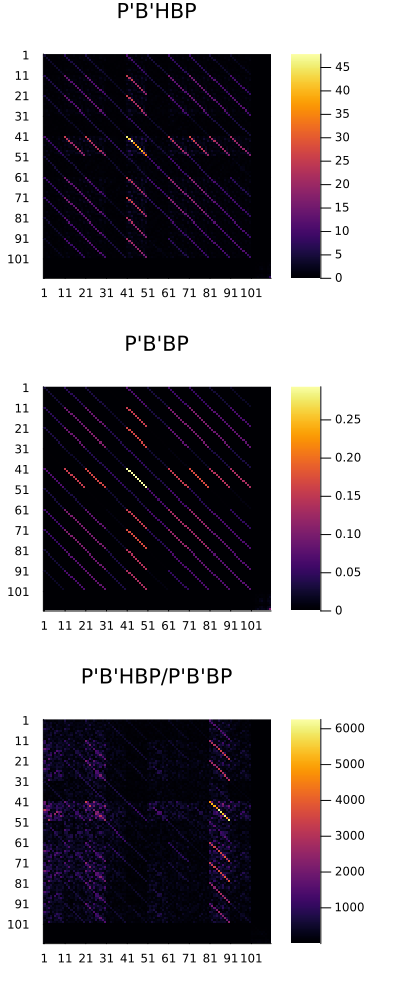

In [35]:
# stateCLL = leftcanonical(stateCLL, true)
P = projection_matrix(D, stateLL.Rs[1][])

ρR = rightenv(stateCLL)[1][]
ρR ./= tr(ρR)
B = left2centre_matrix(ρR)

space = InfiniteCMPSExcitationSpace(0, stateCLL, stateCLL)
Heff = excitation_matrix(excitation_operator(HCLL, space), D);

Hf = P' * B' * Heff * B * P
Nf = P' * B' * B * P

p1 = heatmap(abs.(Hf), yflip=true, size=(400, 400), xticks=1:D:D^2+D, yticks=1:D:D^2+D, title="P'B'HBP")
p2 = heatmap(abs.(Nf), yflip=true, size=(400, 400), xticks=1:D:D^2+D, yticks=1:D:D^2+D, title="P'B'BP")
p3 = heatmap(abs.(Hf / Nf), yflip=true, size=(400, 400), xticks=1:D:D^2+D, yticks=1:D:D^2+D, title="P'B'HBP/P'B'BP")

plot(p1, p2, p3, layout=(3, 1), size=(400, 1000), margins=5Plots.mm)

In [45]:
# TRIVIAL SPECTRUM - ODD/EVEN SECTORS
ρ = real(expval(ψ̂₁' * ψ̂₁ + ψ̂₂' * ψ̂₂, stateCLL)[]);
ps = range(0, 2π * ρ, 20)

spectrum_even = zeros(length(ps), D^2)
spectrum_odd = zeros(length(ps), D)
Threads.@threads for idx in eachindex(ps)
    space = InfiniteCMPSExcitationSpace(ps[idx], stateCLL, stateCLL)
    Heff = excitation_matrix(excitation_operator(HCLL, space), D)
    Hc = P' * B' * Heff * B * P
    Neff = P' * B' * B * P

    spectrum_even[idx, :] .= real.(eigen(Hc[1:D^2, 1:D^2], Neff[1:D^2, 1:D^2]).values)
    spectrum_odd[idx, :] .= real.(eigen(Hc[D^2+1:end, D^2+1:end], Neff[D^2+1:end, D^2+1:end]).values)
end

In [46]:
# TRIVIAL SPECTRUM - FULL SPECTRUM
nvals = 20
trivial_spectrum = zeros(ComplexF64, length(ps), nvals);
trivial_excitations = [[] for _ in eachindex(ps)]

Threads.@threads for idx in eachindex(ps)
    space = InfiniteCMPSExcitationSpace(ps[idx], stateCLL, stateCLL)
    Heff = excitation_matrix(excitation_operator(HCLL, space), D)    
    Neff = P' * B' * B * P
    vals, vecs = eigen(P' * B' * Heff * B * P, Neff)

    trivial_spectrum[idx, :] .= vals[1:nvals]
    trivial_excitations[idx] = map(vecs[1:nvals]) do vec
        Ws = P * vec
        D = floor(Int, sqrt(length(Ws) ÷ 2))
        W₁ = reshape(view(Ws, 1:D^2), D, D)
        W₂ = reshape(view(Ws, (D^2+1):2*D^2), D, D)
        return (W₁, W₂)
    end
end

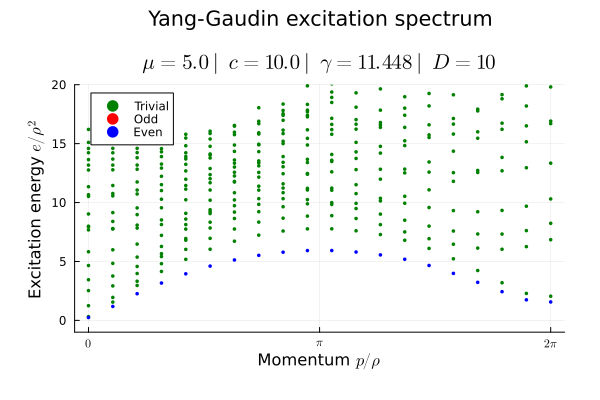

In [47]:
scatter(ps ./ ρ, real.(trivial_spectrum) ./ ρ^2, lab=permutedims(["Trivial"; fill("", nvals - 1)]), ms=2, c=:green, markerstrokewidth=0)
plot!(xtick=pitick(-2π, 2π, 1, mode=:latex), ylabel="Excitation energy " * L"e/\rho^2", xlabel="Momentum " * L"p/\rho", title="Yang-Gaudin excitation spectrum\n\n" * L"\mu=%$(μ) \ | \ c=%$(c) \ | \ \gamma = %$(round(c/ρ, digits=3))\ | \ D=%$(D)", margins=7Plots.mm, ylim=[-1, 20])

scatter!(ps ./ ρ, spectrum_odd[:, 1], lab="Odd", ms=2, markerstrokewidth=0, c=:red)
scatter!(ps ./ ρ, spectrum_even[:, 1], lab="Even", ms=2, markerstrokewidth=0, c=:blue)